In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows and Columns: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                    

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest

In [6]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

In [7]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
print("States:", df['State'].nunique())
print("Crops:", df['Crop'].nunique())
print("Seasons:", df['Season'].nunique())

print("\nCrop Names:")
print(df['Crop'].unique())

print("\nSeason Names:")
print(df['Season'].unique())

States: 8
Crops: 8
Seasons: 3

Crop Names:
<ArrowStringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season Names:
<ArrowStringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str


In [9]:
crop_performance = df.groupby('Crop')[['Yield_Tonnes_Ha', 'Profit_INR']].mean().sort_values('Yield_Tonnes_Ha', ascending=False)

crop_performance

,Yield_Tonnes_Ha,Profit_INR
Crop,,
Sugarcane,46.642361,817187.986885
Maize,2.710036,-83978.326679
Rice,2.431304,-102213.504348
Wheat,2.108013,-123398.337134
Chilli,1.542767,750878.342233
Groundnut,1.322901,44858.120283
Cotton,1.229783,124546.915354
Pulses,0.921512,-4238.052419


In [10]:
season_performance = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].mean().sort_values('Profit_INR', ascending=False)

season_performance

,Yield_Tonnes_Ha,Profit_INR
Season,,
Kharif,5.628612,178914.647555
Rabi,5.039435,87689.470191
Zaid,4.641313,-24804.824916


In [11]:
state_performance = df.groupby('State')[['Yield_Tonnes_Ha', 'Profit_INR']].mean().sort_values('Profit_INR', ascending=False)

state_performance

,Yield_Tonnes_Ha,Profit_INR
State,,
Punjab,6.121116,136025.636364
Maharashtra,5.017480,135428.855469
Karnataka,5.685481,119422.335378
Tamil Nadu,4.875175,117744.748454
Gujarat,5.659016,117568.235656
Telangana,5.044477,108829.616279
Madhya Pradesh,4.989940,86840.756539
Andhra Pradesh,4.628771,73453.527410


In [12]:
crop_season = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().unstack()

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


In [13]:
avg_profit_crop = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

avg_profit_crop

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64

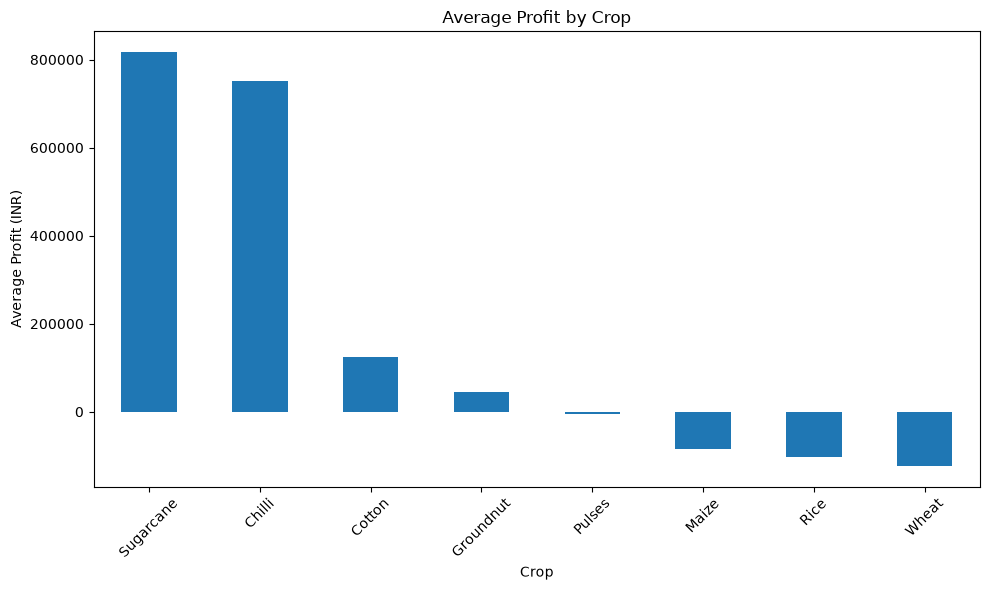

In [14]:
plt.figure(figsize=(10,6))

avg_profit_crop.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

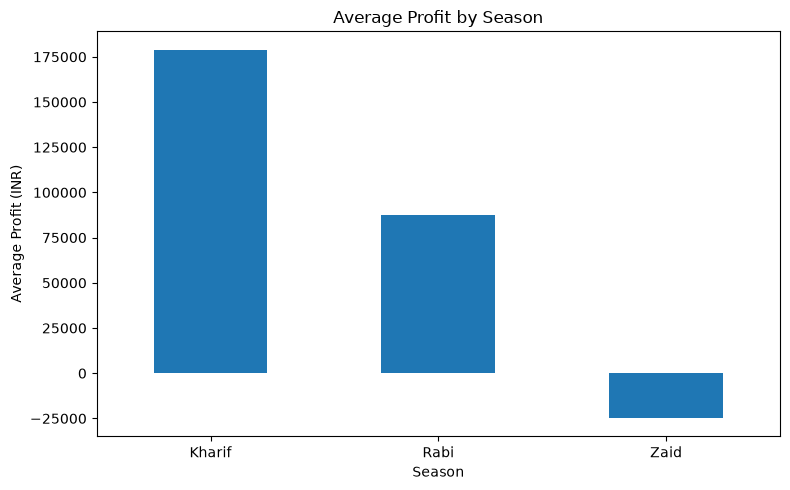

In [15]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

season_profit.plot(kind='bar', figsize=(8,5))

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

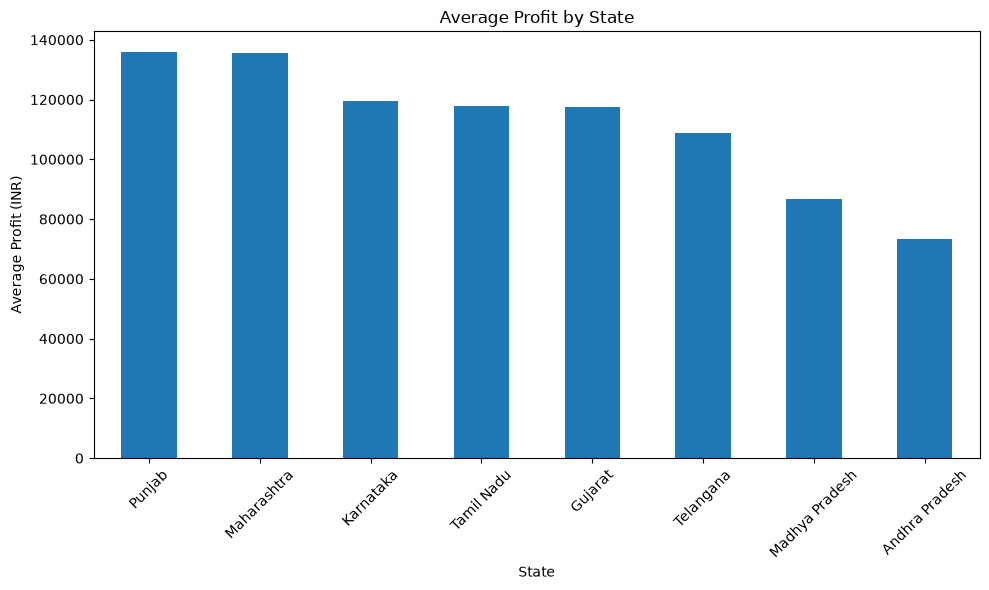

In [16]:
plt.figure(figsize=(10,6))

state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

state_profit.plot(kind='bar')

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

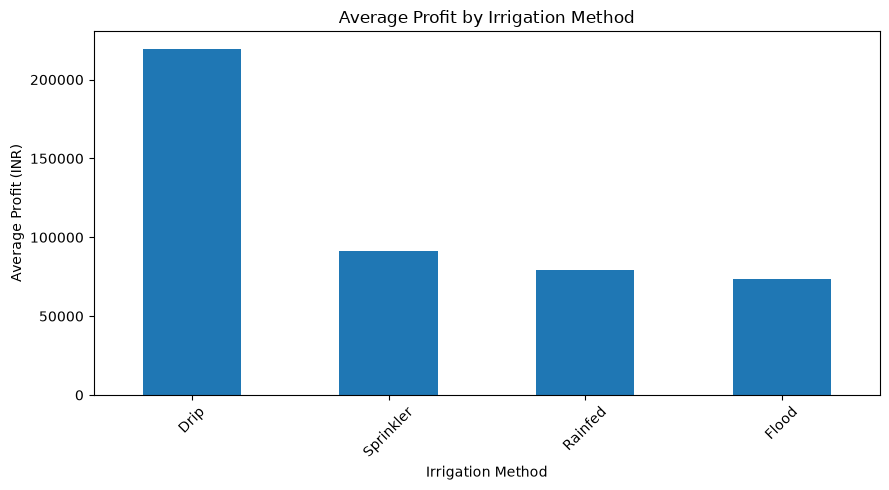

In [17]:
irrigation_profit = df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False)

irrigation_profit.plot(kind='bar', figsize=(9,5))

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

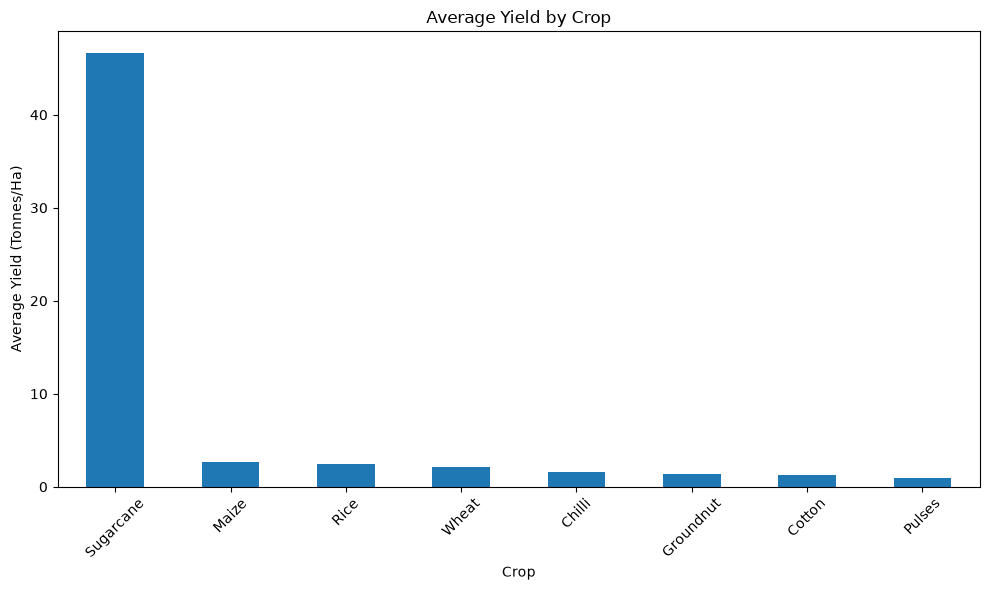

In [18]:
avg_yield_crop = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

avg_yield_crop.plot(kind='bar', figsize=(10,6))

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

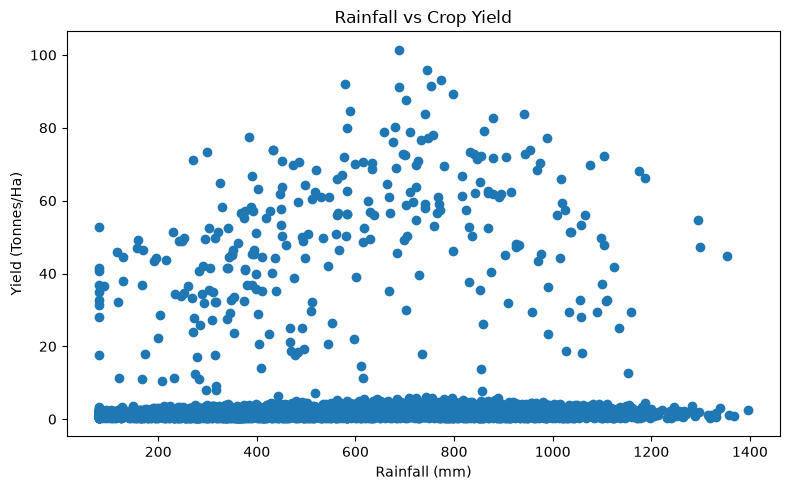

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

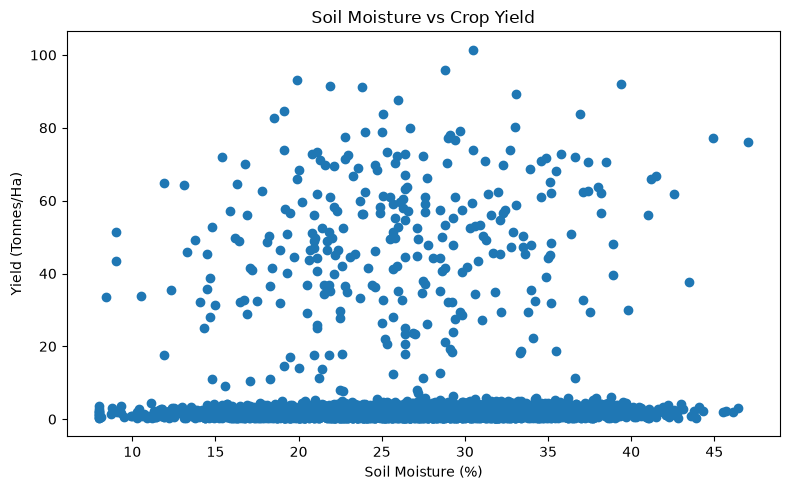

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['Soil_Moisture_pct'], df['Yield_Tonnes_Ha'])

plt.title('Soil Moisture vs Crop Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

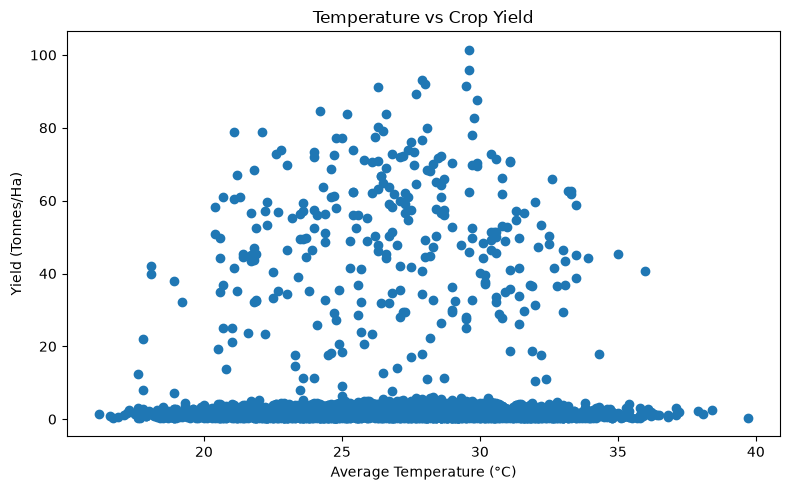

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df['Avg_Temperature_C'], df['Yield_Tonnes_Ha'])

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

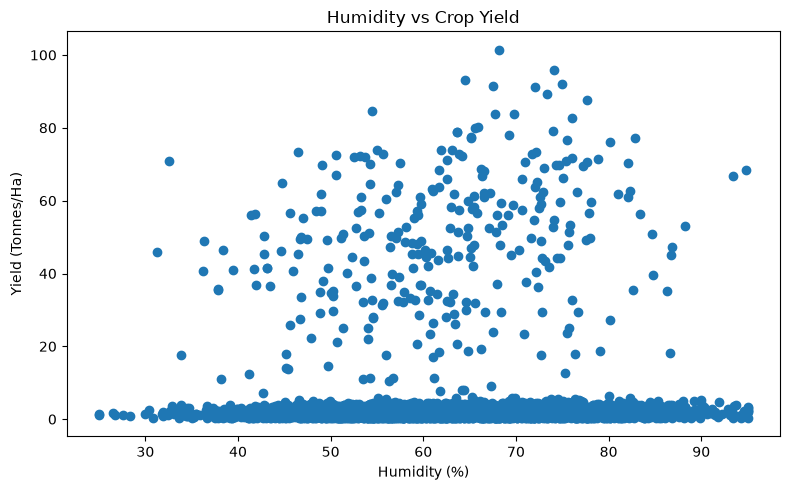

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df['Humidity_pct'], df['Yield_Tonnes_Ha'])

plt.title('Humidity vs Crop Yield')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

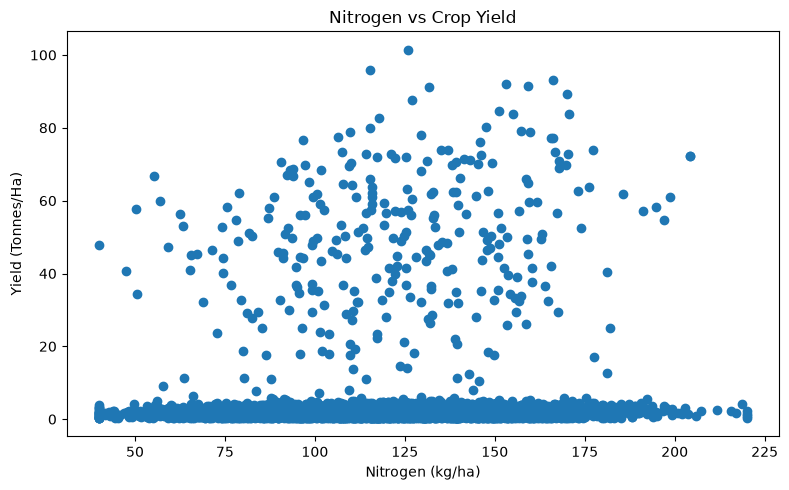

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(df['Nitrogen_kg_ha'], df['Yield_Tonnes_Ha'])

plt.title('Nitrogen vs Crop Yield')
plt.xlabel('Nitrogen (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

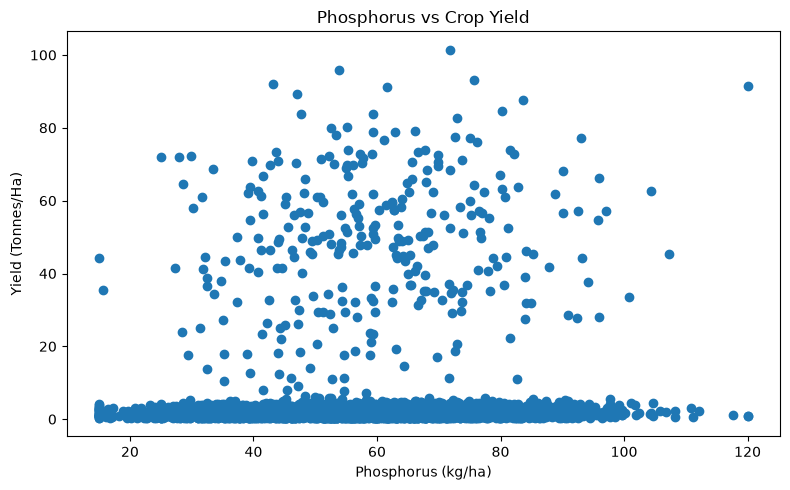

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df['Phosphorus_kg_ha'], df['Yield_Tonnes_Ha'])

plt.title('Phosphorus vs Crop Yield')
plt.xlabel('Phosphorus (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

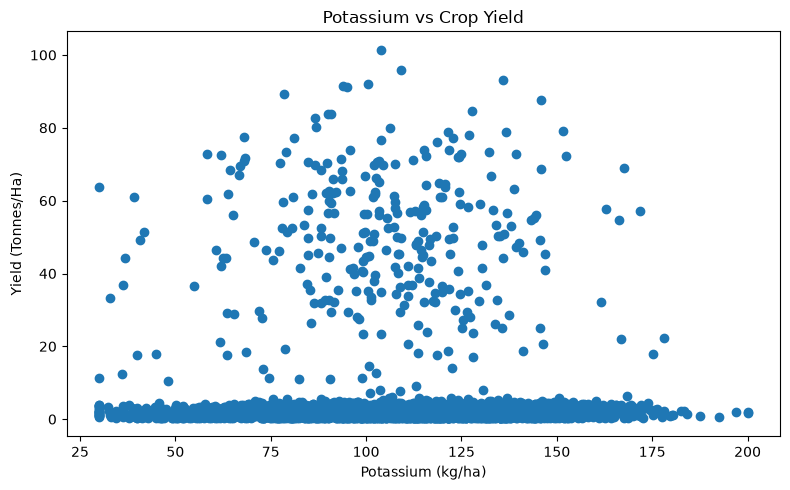

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(df['Potassium_kg_ha'], df['Yield_Tonnes_Ha'])

plt.title('Potassium vs Crop Yield')
plt.xlabel('Potassium (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

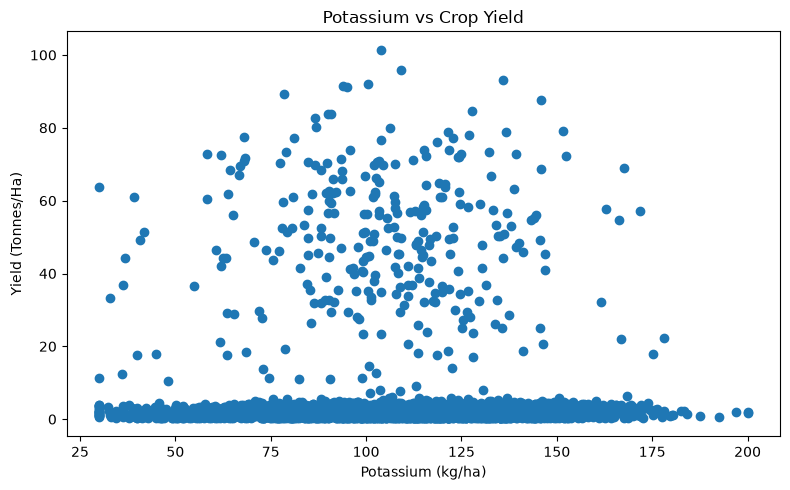

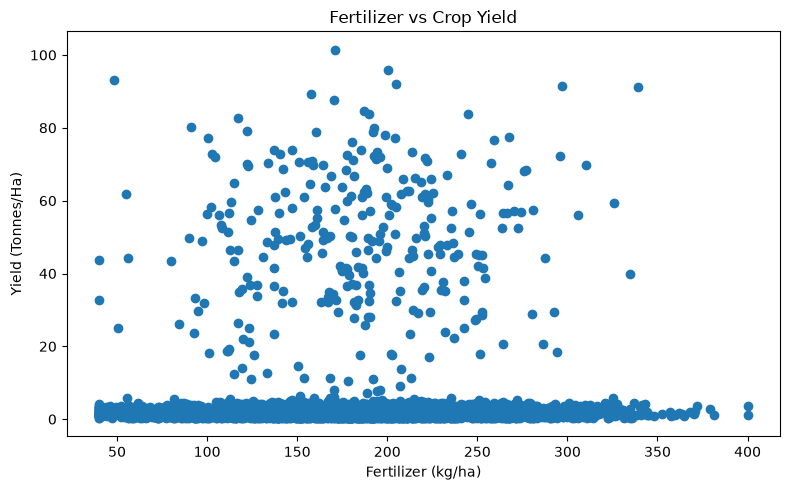

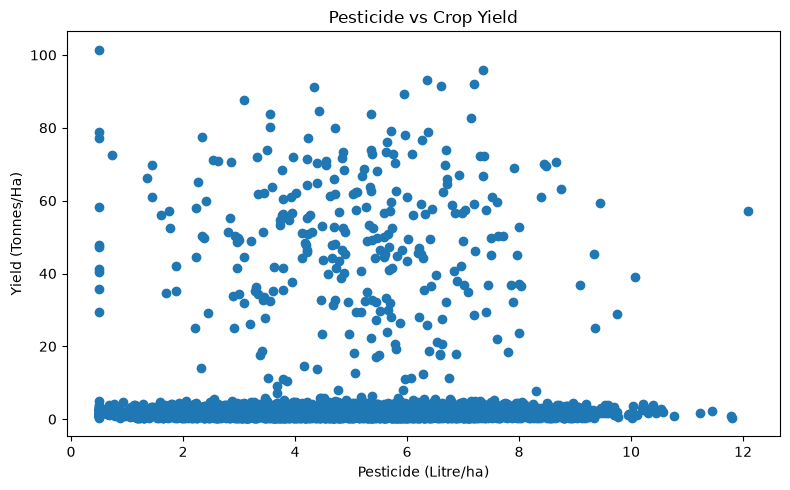

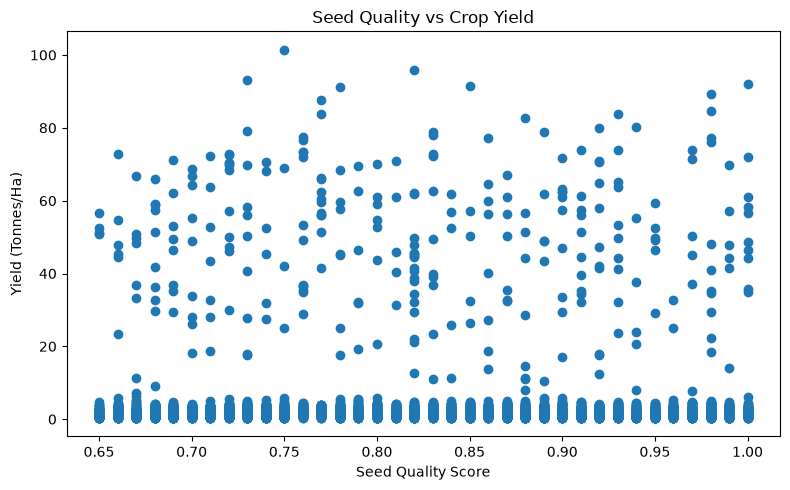

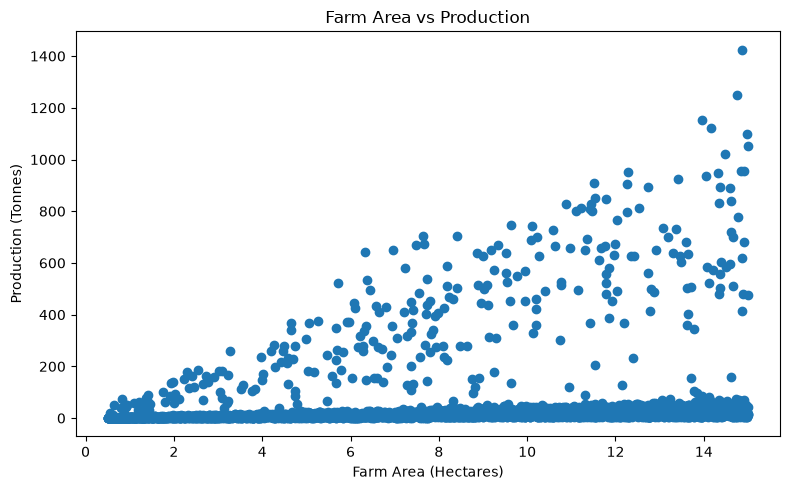

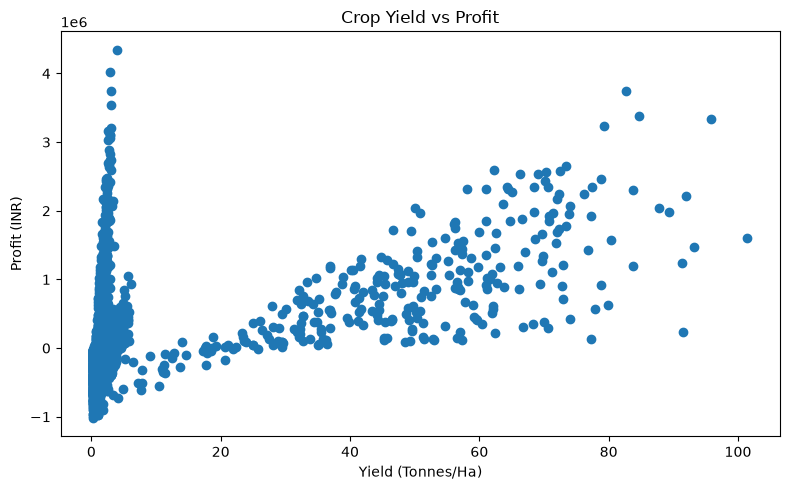

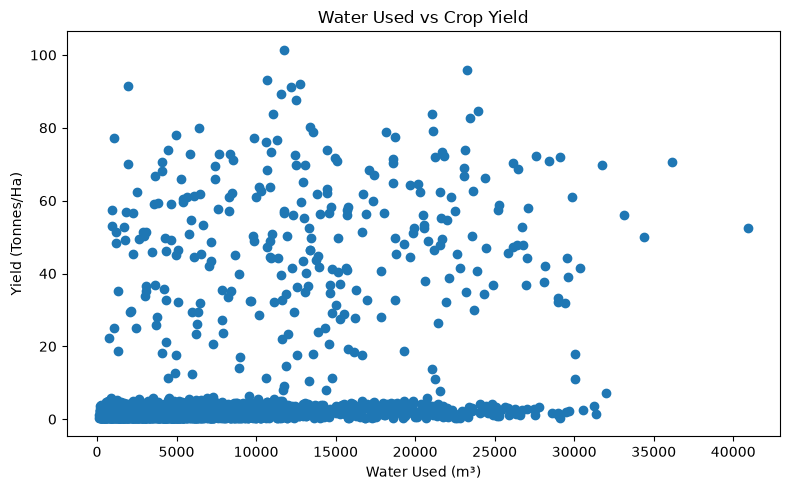

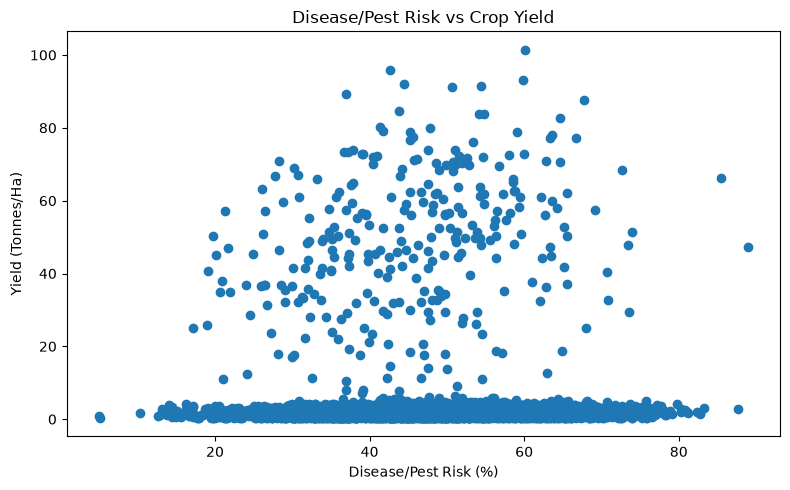

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['Potassium_kg_ha'], df['Yield_Tonnes_Ha'])
plt.title('Potassium vs Crop Yield')
plt.xlabel('Potassium (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Fertilizer_kg_ha'], df['Yield_Tonnes_Ha'])
plt.title('Fertilizer vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Pesticide_Litre_ha'], df['Yield_Tonnes_Ha'])
plt.title('Pesticide vs Crop Yield')
plt.xlabel('Pesticide (Litre/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Seed_Quality_Score'], df['Yield_Tonnes_Ha'])
plt.title('Seed Quality vs Crop Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Farm_Area_Hectares'], df['Production_Tonnes'])
plt.title('Farm Area vs Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Yield_Tonnes_Ha'], df['Profit_INR'])
plt.title('Crop Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Water_Used_m3'], df['Yield_Tonnes_Ha'])
plt.title('Water Used vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['Disease_Pest_Risk_pct'], df['Yield_Tonnes_Ha'])
plt.title('Disease/Pest Risk vs Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

In [27]:
correlation = df.select_dtypes(include='number').corr()

print("Correlation with Crop Yield:")
print(correlation['Yield_Tonnes_Ha'].sort_values(ascending=False))

print("\nCorrelation with Profit:")
print(correlation['Profit_INR'].sort_values(ascending=False))

Correlation with Crop Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64

Correlat

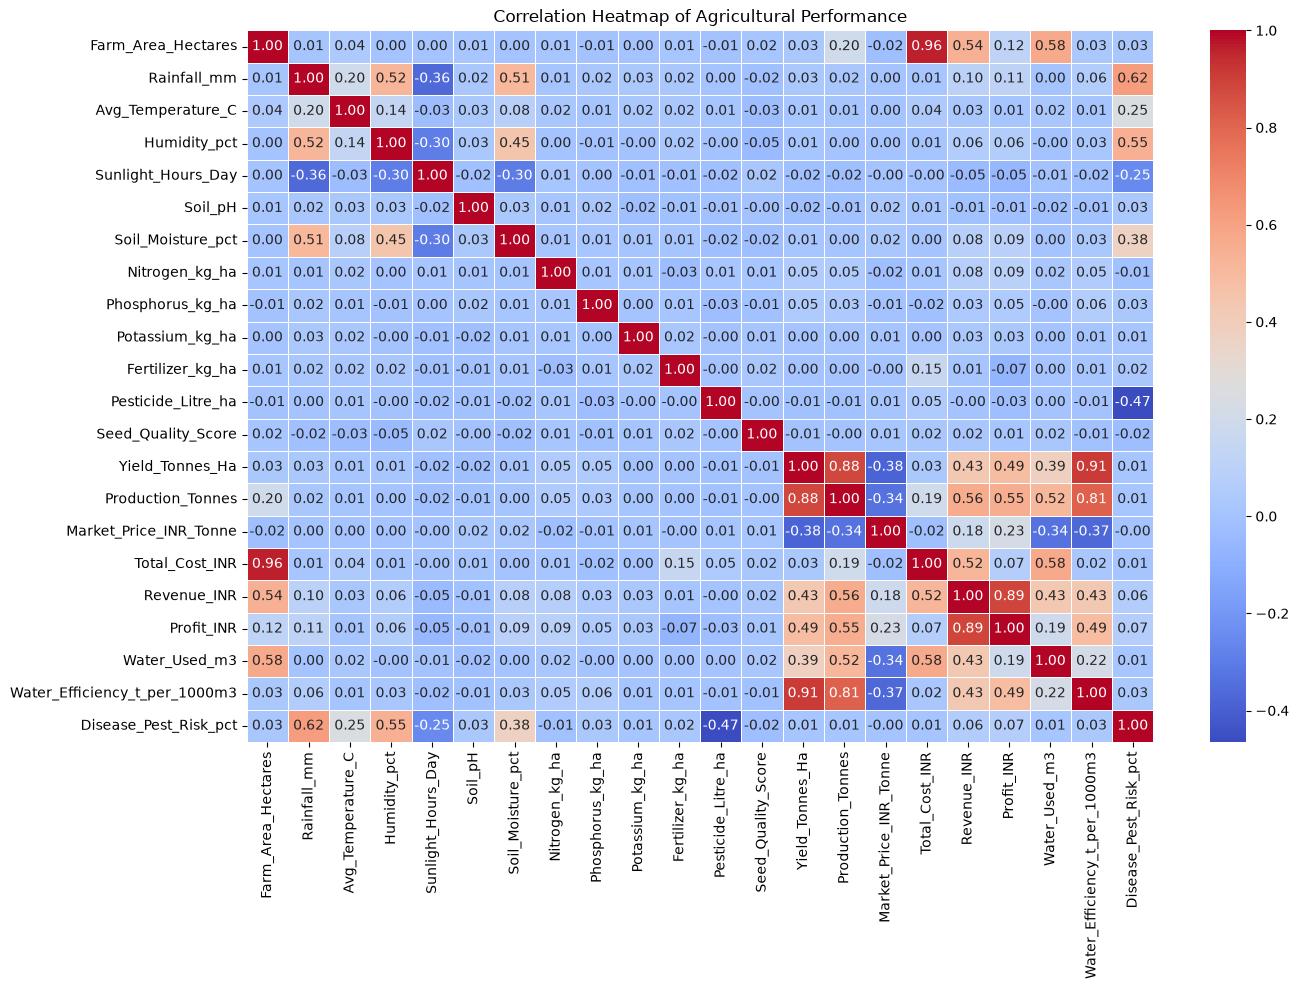

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Agricultural Performance')
plt.tight_layout()
plt.show()

In [29]:
print("KEY FINDINGS")
print("-" * 50)

print("1. Kharif season has the highest average profit.")
print("2. Sugarcane has the highest average yield and profit.")
print("3. Drip irrigation provides the highest average profit.")
print("4. Punjab has the highest average profit among the states.")
print("5. Water efficiency has the strongest correlation with crop yield.")
print("6. Revenue has a strong positive correlation with profit.")
print("7. Production has a strong positive correlation with crop yield.")

print("\nCONCLUSION")
print("-" * 50)
print("The analysis shows that crop yield and profitability are influenced")
print("by factors such as water efficiency, crop type, season and irrigation.")
print("Sugarcane and drip irrigation show strong performance, while")
print("efficient water management can significantly improve agricultural yield.")

KEY FINDINGS
--------------------------------------------------
1. Kharif season has the highest average profit.
2. Sugarcane has the highest average yield and profit.
3. Drip irrigation provides the highest average profit.
4. Punjab has the highest average profit among the states.
5. Water efficiency has the strongest correlation with crop yield.
6. Revenue has a strong positive correlation with profit.
7. Production has a strong positive correlation with crop yield.

CONCLUSION
--------------------------------------------------
The analysis shows that crop yield and profitability are influenced
by factors such as water efficiency, crop type, season and irrigation.
Sugarcane and drip irrigation show strong performance, while
efficient water management can significantly improve agricultural yield.
